In [ ]:
!pip install tensorflow

In [3]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder, OneHotEncoder
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, roc_curve, auc
import matplotlib.pyplot as plt
import seaborn as sns
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam

In [ ]:
# Load the Titanic dataset from the source URL
url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
data = pd.read_csv(url)

# Display the first few rows and info
print(data.head())
print(data.info())

In [ ]:
# Handling Missing Values
# Fill missing Age with median
data['Age'].fillna(data['Age'].median(), inplace=True)

# Fill missing Embarked with mode (most common value)
data['Embarked'].fillna(data['Embarked'].mode()[0], inplace=True)

# Drop Cabin (too many missing values, and not crucial for simple model)
data.drop('Cabin', axis=1, inplace=True)

# Drop irrelevant features
data.drop(['PassengerId', 'Name', 'Ticket'], axis=1, inplace=True)

# Encoding Categorical Data
# Encode Sex: male=0, female=1
label_encoder = LabelEncoder()
data['Sex'] = label_encoder.fit_transform(data['Sex'])

# One-hot encode Embarked
embarked_onehot = pd.get_dummies(data['Embarked'], prefix='Embarked')
data = pd.concat([data, embarked_onehot], axis=1)
data.drop('Embarked', axis=1, inplace=True)

# Separate features and target
X = data.drop('Survived', axis=1)
y = data['Survived']

# Feature Scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Splitting Data into train and test (80/20 split)
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

# Display shapes
print(f"X_train shape: {X_train.shape}, y_train shape: {y_train.shape}")
print(f"X_test shape: {X_test.shape}, y_test shape: {y_test.shape}")

In [6]:
# Define the Neural Network Architecture
model = Sequential()

# Input layer (implicit) + first hidden layer with ReLU
model.add(Dense(units=64, activation='relu', input_dim=X_train.shape[1]))

# Second hidden layer with ReLU
model.add(Dense(units=32, activation='relu'))

# Output layer with sigmoid for binary classification
model.add(Dense(units=1, activation='sigmoid'))

# Compile the Model
model.compile(optimizer=Adam(learning_rate=0.001),
              loss='binary_crossentropy',
              metrics=['accuracy'])

# Summary of the model
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │           640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,753 (10.75 KB)

 Trainable params: 2,753 (10.75 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 2s 45ms/step - accuracy: 0.6007 - loss: 0.6620 - val_accuracy: 0.7273 - val_loss: 0.5838
Epoch 2/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.7555 - loss: 0.5576 - val_accuracy: 0.8042 - val_loss: 0.5192
Epoch 3/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - accuracy: 0.7785 - loss: 0.5193 - val_accuracy: 0.8182 - val_loss: 0.4738
Epoch 4/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - accuracy: 0.8143 - loss: 0.4649 - val_accuracy: 0.7832 - val_loss: 0.4436
Epoch 5/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.7849 - loss: 0.4829 - val_accuracy: 0.8252 - val_loss: 0.4228
Epoch 6/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.7972 - loss: 0.4614 - val_accuracy: 0.8252 - val_loss: 0.4165
Epoch 7/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step - accuracy: 0.8304 - loss: 0.4445 - val_accuracy: 0.8252 - val_loss: 0.4069
Epoch 8/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step - accuracy: 0.8522 - loss: 0.3955 - val_accuracy: 0.8322 - v

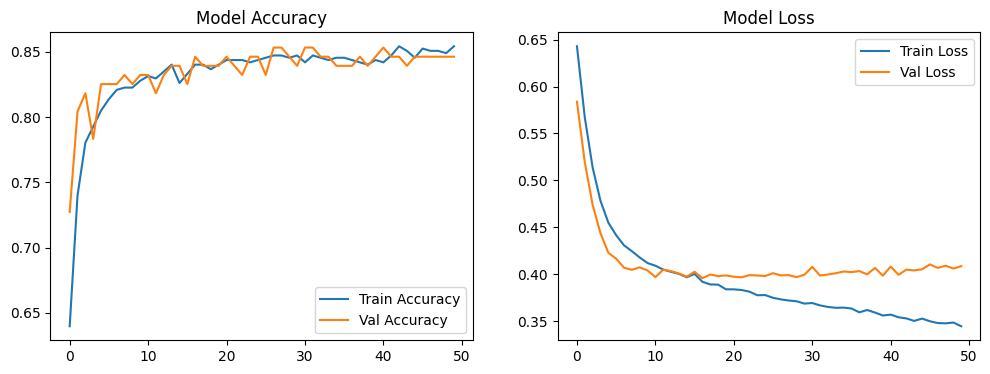

In [7]:
# Train the Model
history = model.fit(X_train, y_train,
                    epochs=50,  # You can adjust epochs
                    batch_size=32,  # Batch size
                    validation_split=0.2,  # 20% of train for validation to monitor overfitting
                    verbose=1)

# Plot training history to check for overfitting
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title('Model Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Model Loss')
plt.legend()
plt.show()

6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 76ms/step
Accuracy: 0.8212
Precision: 0.8281
Recall: 0.7162
F1-Score: 0.7681


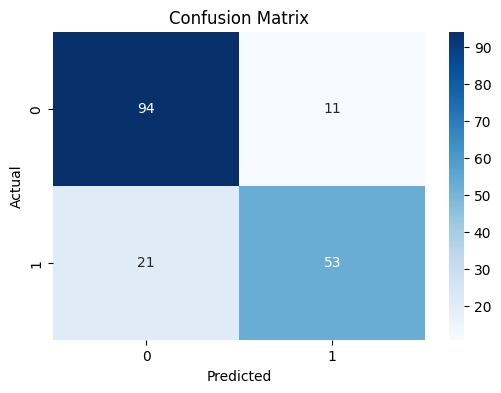

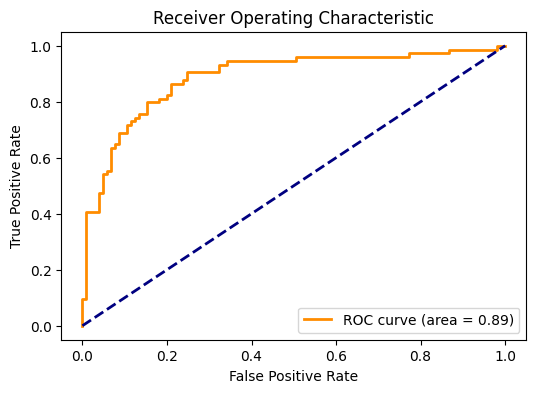

In [8]:
# Predict on test set
y_pred_prob = model.predict(X_test)
y_pred = (y_pred_prob > 0.5).astype(int)

# Assess metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-Score: {f1:.4f}")

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_pred_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6, 4))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.title('Receiver Operating Characteristic')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.show()